# Importing data and libraries

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from palmerpenguins import load_penguins
import numpy as np

In [5]:
data = load_penguins()
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 21.6 KB


# Visualizations

## Pandas

In [6]:
# Stack bars
# summary = data.groupby('species').agg({'bill_length_mm': 'mean', 'bill_depth_mm': 'mean', 'flipper_length_mm': 'mean'})
# summary.plot(kind='bar', stacked=True, ax=ax[4, 1], color=['red', 'blue', 'green'], width=0.5)
# ax[4, 1].set_title('Stack bars - OPTION 1')
# ax[4, 1].set_xticklabels(species, rotation=0)
# ax[4, 1].set_xlabel('Species')
# ax[4, 1].set_ylabel('Mean')

## Matplotlib

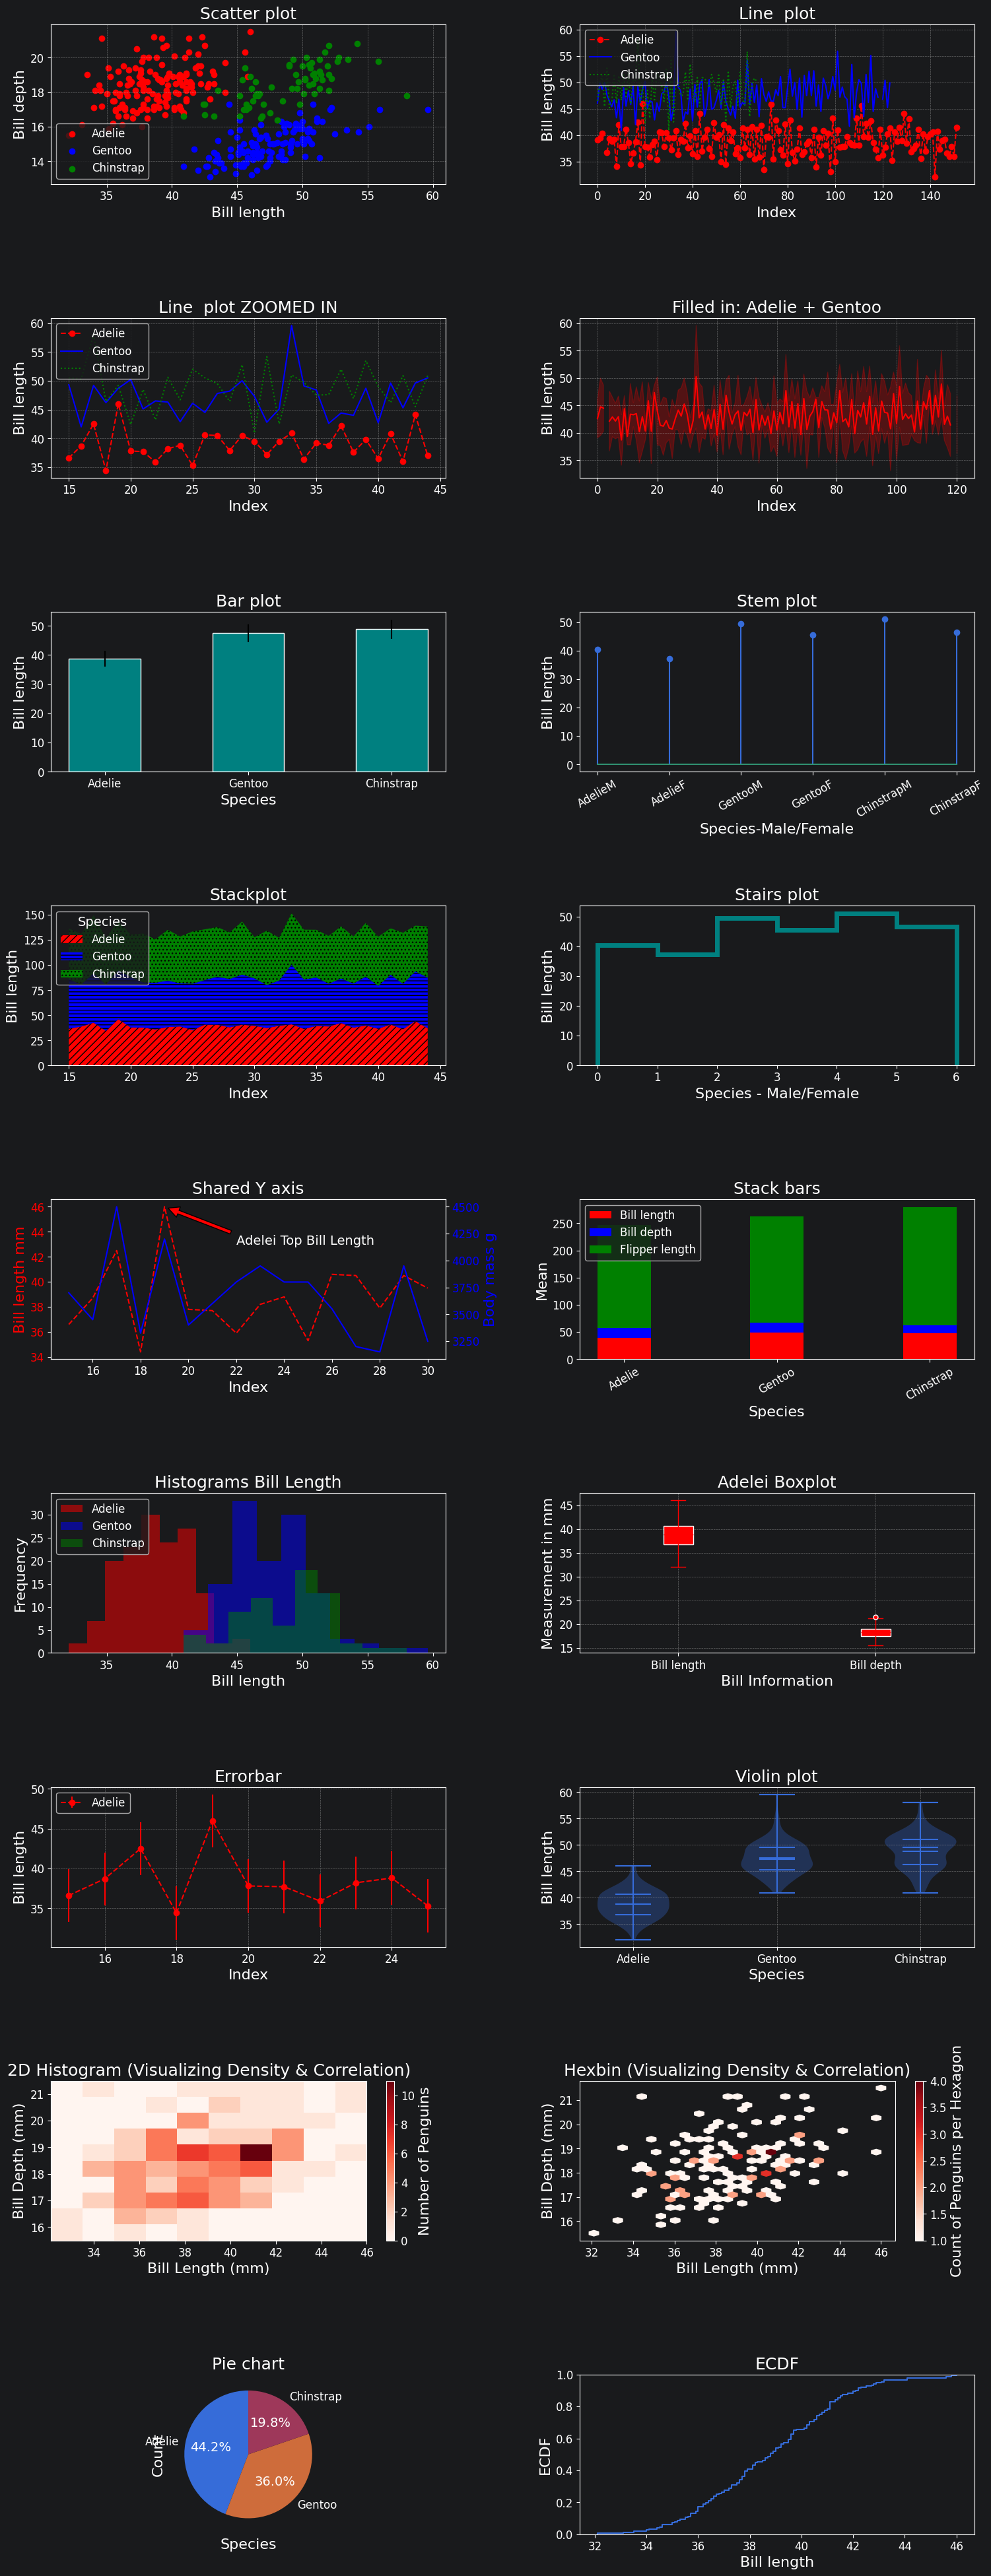

In [66]:
adelei = data[data.species == 'Adelie']
gentoo = data[data.species == 'Gentoo']
chinstrap = data[data.species == 'Chinstrap']

plt.rc('font', size=14)          # Controls default text sizes
plt.rc('axes', titlesize=18)     # Size of the subplot titles
plt.rc('axes', labelsize=16)     # Size of the x and y labels
plt.rc('xtick', labelsize=12)    # Size of the tick labels
plt.rc('ytick', labelsize=12)    # Size of the tick labels
plt.rc('legend', fontsize=12)    # Legend text size

fig, ax = plt.subplots(9, 2, figsize=(16, 40))

# Scatter plot
ax[0, 0].scatter(adelei.bill_length_mm, adelei.bill_depth_mm, color='red', label='Adelie')
ax[0, 0].scatter(gentoo.bill_length_mm, gentoo.bill_depth_mm, color='blue', label='Gentoo')
ax[0, 0].scatter(chinstrap.bill_length_mm, chinstrap.bill_depth_mm, color='green', label='Chinstrap')
ax[0, 0].legend(loc='lower left')
ax[0, 0].set_title('Scatter plot')
ax[0, 0].set_xlabel('Bill length')
ax[0, 0].set_ylabel('Bill depth')
ax[0, 0].grid(True, linestyle='--', which='major', axis='both')

# Line plot
ax[0, 1].plot(np.arange(0, adelei.shape[0]), adelei['bill_length_mm'], color='red', label='Adelie', linestyle='--', marker='o')
ax[0, 1].plot(np.arange(0, gentoo.shape[0]), gentoo['bill_length_mm'], color='blue', label='Gentoo', linestyle='-')
ax[0, 1].plot(np.arange(0, chinstrap.shape[0]), chinstrap['bill_length_mm'], color='green', label='Chinstrap', linestyle=':')
ax[0, 1].legend(loc='upper left')
ax[0, 1].set_title('Line  plot')
ax[0, 1].set_xlabel('Index')
ax[0, 1].set_ylabel('Bill length')
ax[0, 1].grid(True, linestyle='--', which='major', axis='both')

# Line plot ZOOMED IN
zoomed_in = np.arange(15, 45)
ax[1,0].plot(zoomed_in, adelei['bill_length_mm'].iloc[15:45], color='red', label='Adelie', linestyle='--', marker='o')
ax[1,0].plot(zoomed_in, gentoo['bill_length_mm'].iloc[15:45], color='blue', label='Gentoo', linestyle='-')
ax[1,0].plot(zoomed_in, chinstrap['bill_length_mm'].iloc[15:45], color='green', label='Chinstrap', linestyle=':')
ax[1,0].legend(loc='upper left')
ax[1,0].set_title('Line  plot ZOOMED IN')
ax[1,0].set_xlabel('Index')
ax[1,0].set_ylabel('Bill length')
ax[1,0].grid(True, linestyle='--', which='major', axis='both')

# Filled in
between = np.arange(0, 121)
adelei_120 = adelei['bill_length_mm'].iloc[0:121]
gentoo_120 = gentoo['bill_length_mm'].iloc[0:121]
ax[1, 1].fill_between(between, adelei_120, gentoo_120, color='red', alpha=0.25)
ax[1, 1].plot(between, (adelei_120.values + gentoo_120.values)/2, color='red', linestyle='-')
ax[1, 1].set_title('Filled in: Adelie + Gentoo')
ax[1, 1].set_xlabel('Index')
ax[1, 1].set_ylabel('Bill length')
ax[1, 1].grid(True, linestyle='--', which='major', axis='both')

# Bar plot (X vs. Height)
species = ['Adelie', 'Gentoo', 'Chinstrap']
bill_length_mean = [adelei.bill_length_mm.mean(), gentoo.bill_length_mm.mean(), chinstrap.bill_length_mm.mean()]
bill_length_std = [adelei.bill_length_mm.std(), gentoo.bill_length_mm.std(), chinstrap.bill_length_mm.std()]
ax[2, 0].bar(species, bill_length_mean, color='teal', edgecolor='white', width=0.5, yerr=bill_length_std)
ax[2, 0].set_title('Bar plot')
ax[2, 0].set_xlabel('Species')
ax[2, 0].set_ylabel('Bill length')

# Stem plot (useful when there are too many categorical variables)
species_sex = ['AdelieM', 'AdelieF', 'GentooM', 'GentooF', 'ChinstrapM', 'ChinstrapF']
bill_length_sex = [adelei.query('sex == "male"').bill_length_mm.mean(), adelei.query('sex == "female"').bill_length_mm.mean(), gentoo.query('sex == "male"').bill_length_mm.mean(), gentoo.query('sex == "female"').bill_length_mm.mean(), chinstrap.query('sex == "male"').bill_length_mm.mean(), chinstrap.query('sex == "female"').bill_length_mm.mean()]
ax[2, 1].stem(species_sex, bill_length_sex)
ax[2, 1].set_title('Stem plot')
ax[2, 1].set_xticks(range(len(species_sex)))
ax[2, 1].set_xticklabels(species_sex, rotation=30)
ax[2, 1].set_xlabel('Species-Male/Female')
ax[2, 1].set_ylabel('Bill length')

# Stackplot
bill_zoom_matrix = np.vstack([adelei['bill_length_mm'].iloc[15:45], gentoo['bill_length_mm'].iloc[15:45], chinstrap['bill_length_mm'].iloc[15:45]])
ax[3, 0].stackplot(zoomed_in, bill_zoom_matrix, labels=['Adelie', 'Gentoo', 'Chinstrap'], baseline='zero', colors=['red', 'blue', 'green'], hatch=['///', '---', '...'])
ax[3, 0].set_title('Stackplot')
ax[3, 0].set_xlabel('Index')
ax[3, 0].set_ylabel('Bill length')
ax[3, 0].legend(loc='upper left', title='Species')

# Stairs
ax[3, 1].stairs(bill_length_sex, linewidth=5, fill=False, color='teal', orientation='vertical')
ax[3, 1].set_title('Stairs plot')
ax[3, 1].set_xlabel('Species - Male/Female')
ax[3, 1].set_ylabel('Bill length')

# Shared Y axis
zoomed_in = np.arange(15, 31)
ax[4, 0].plot(zoomed_in, adelei['bill_length_mm'].iloc[15:31], color='red', linestyle='--')
ax[4, 0].set_title('Shared Y axis')
ax[4, 0].set_xlabel('Index')
ax[4, 0].set_ylabel('Bill length mm', color='red')
ax[4, 0].tick_params(axis='y', labelcolor='red')
ax[4, 0].annotate('Adelei Top Bill Length', xy=(19, 46), xytext=(22, 43), arrowprops=dict(facecolor='red', shrink=0.05))

ax2 = ax[4, 0].twinx()
ax2.plot(zoomed_in, adelei['body_mass_g'].iloc[15:31], color='blue', linestyle='-')
ax2.set_ylabel('Body mass g', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# Stack bars
ax[4, 1].bar(summary.index, summary['bill_length_mm'], width=0.35, label='Bill length', color='red')
ax[4, 1].bar(summary.index, summary['bill_depth_mm'], bottom=summary['bill_length_mm'], width=0.35, label='Bill depth', color='blue')
ax[4, 1].bar(summary.index, summary['flipper_length_mm'], bottom=summary['bill_length_mm'] + summary['bill_depth_mm'], width=0.35, label='Flipper length', color='green')
ax[4, 1].legend(loc='upper left')
ax[4, 1].set_title('Stack bars')
ax[4, 1].set_xticks(range(len(species)))
ax[4, 1].set_xticklabels(species, rotation=30)
ax[4, 1].set_xlabel('Species')
ax[4, 1].set_ylabel('Mean')

# Histograms
ax[5, 0].hist(adelei['bill_length_mm'], bins=10, color='red', alpha=0.5, label='Adelie', histtype='bar')
ax[5, 0].hist(gentoo['bill_length_mm'], bins=10, color='blue', alpha=0.5, label='Gentoo', histtype='bar')
ax[5, 0].hist(chinstrap['bill_length_mm'], bins=10, color='green', alpha=0.5, label='Chinstrap', histtype='bar')
ax[5, 0].legend(loc='upper left')
ax[5, 0].set_title('Histograms Bill Length')
ax[5, 0].set_xlabel('Bill length')
ax[5, 0].set_ylabel('Frequency')

# Boxplot
ax[5, 1].boxplot([adelei['bill_length_mm'].ffill(), adelei['bill_depth_mm'].ffill()], tick_labels=['Bill length', 'Bill depth'], patch_artist=True, boxprops=dict(facecolor='red'), whiskerprops=dict(color='red'), flierprops=dict(marker='o', markerfacecolor='red', markersize=5), medianprops=dict(color='red'), capprops=dict(color='red'))
ax[5, 1].set_title('Adelei Boxplot')
ax[5, 1].set_xlabel('Bill Information')
ax[5, 1].set_ylabel('Measurement in mm')
ax[5, 1].grid(True, linestyle='--', which='major', axis='both')

# Errorbar
ax[6,0].errorbar(np.arange(15, 26), adelei['bill_length_mm'].iloc[15:26], yerr=adelei['bill_length_mm'].iloc[15:26].std(), color='red', linestyle='--', marker='o', label='Adelie')
ax[6,0].legend(loc='upper left')
ax[6,0].set_title('Errorbar')
ax[6,0].set_xlabel('Index')
ax[6,0].set_ylabel('Bill length')
ax[6,0].grid(True, linestyle='--', which='major', axis='both')

# Violin plot
quantiles = [[0, 0.25, 0.5, 0.75, 1], [0, 0.25, 0.5, 0.75, 1], [0, 0.25, 0.5, 0.75, 1]]
ax[6, 1].violinplot([adelei['bill_length_mm'].ffill(), gentoo['bill_length_mm'].ffill(), chinstrap['bill_length_mm'].ffill()], showmeans=True, showmedians=True, showextrema=True, quantiles=quantiles)
ax[6, 1].set_title('Violin plot')
ax[6, 1].set_xlabel('Species')
ax[6, 1].set_ylabel('Bill length')
ax[6, 1].grid(True, linestyle='--', which='major', axis='both')
ax[6, 1].set_xticks([1, 2, 3])
ax[6, 1].set_xticklabels(['Adelie', 'Gentoo', 'Chinstrap'])

# Histogram 2D
counts, xedges, yedges, im = ax[7, 0].hist2d(adelei['bill_length_mm'].ffill(), adelei['bill_depth_mm'].ffill(), bins=10, cmap='Reds')
fig.colorbar(im, ax=ax[7, 0], label='Number of Penguins')
ax[7, 0].set_title('2D Histogram (Visualizing Density & Correlation)')
ax[7, 0].set_xlabel('Bill Length (mm)')
ax[7, 0].set_ylabel('Bill Depth (mm)')

# Hexbin
# counts, xedges, yedges, im = ax[7, 1].hexbin(adelei['bill_length_mm'].ffill(), adelei['bill_depth_mm'].ffill(), bins=10, cmap='Reds')
# fig.colorbar(im, ax=ax[7, 1], label='Number of Penguins')
hb = ax[7, 1].hexbin(adelei['bill_length_mm'].ffill(), adelei['bill_depth_mm'].ffill(), gridsize=30, cmap='Reds', mincnt=1)
fig.colorbar(hb, ax=ax[7,1], label='Count of Penguins per Hexagon')
ax[7, 1].set_title('Hexbin (Visualizing Density & Correlation)')
ax[7, 1].set_xlabel('Bill Length (mm)')
ax[7, 1].set_ylabel('Bill Depth (mm)')

# Pie chart
species_count = data.species.value_counts()
ax[8, 0].pie(species_count, labels=species_count.index, autopct='%1.1f%%', startangle=90)
ax[8, 0].set_title('Pie chart')
ax[8, 0].set_xlabel('Species')
ax[8, 0].set_ylabel('Count')

# ECDF
ax[8, 1].ecdf(adelei['bill_length_mm'].ffill(), label='Adelie')
ax[8, 1].set_title('ECDF')
ax[8, 1].set_xlabel('Bill length')
ax[8, 1].set_ylabel('ECDF')


plt.tight_layout(pad=3.0, h_pad=4.0, w_pad=3.0)
plt.show()

## Seaborn

### Lineplot

In [ ]:
fig, axes = plt.subplots(2,1, figsize=(10,10))

sns.lineplot(data=data, x="bill_length_mm", y="bill_depth_mm", ax=axes[0])
axes[0].set_title('Line plot')
axes[0].set_xlabel('Bill length')
axes[0].set_ylabel('Bill depth')
axes[0].grid(True, linestyle='--', which='major', axis='both')

plt.show()

# DRAFT

In [21]:
adelei['bill_length_mm'].std()

np.float64(2.663404848368619)

In [ ]:
data.query('species == "Adelie"')['sex'].value_counts()

In [ ]:
data.query('species == "Adelie"')['sex']

In [ ]:
np.vstack([adelei['bill_length_mm'].iloc[15:45], gentoo['bill_length_mm'].iloc[15:45]])

In [ ]:
adelei.query('sex == "male"')

In [ ]:
import matplotlib.pyplot as plt

# X: True numerical vector (Continuous hours of operation)
hours_of_day = [9, 10, 11, 12, 13]

# Y: True numerical vector (Average hourly foot traffic)
avg_customers = [15, 45, 110, 150, 85]

# Plotting the bars
plt.bar(hours_of_day, avg_customers, color='teal', width=0.8)

# Labeling the continuous numerical data
plt.xlabel('Hour of the Day (24-Hour Clock)')
plt.ylabel('Average Customer Count')
plt.title('Hourly Customer Traffic for Staffing Allocation')

# Ste

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('_mpl-gallery')

# make data:
x = 0.5 + np.arange(8)
y = [4.8, 5.5, 3.5, 4.6, 6.5, 6.6, 2.6, 3.0]

# plot
fig, ax = plt.subplots()

ax.bar(x, y, width=1, edgecolor="white", linewidth=0.7)

ax.set(xlim=(0, 8), xticks=np.arange(1, 8),
       ylim=(0, 8), yticks=np.arange(1, 8))

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('_mpl-gallery')

# make data
y = [4.8, 5.5, 3.5, 4.6, 6.5, 6.6, 2.6, 3.0]

# plot
fig, ax = plt.subplots()

ax.stairs(y, linewidth=1.5)

ax.set(xlim=(0, 8), xticks=np.arange(1, 8),
       ylim=(0, 8), yticks=np.arange(1, 8))

plt.show()

In [ ]:
adelei_120 = adelei['bill_length_mm'].iloc[0:121].ffill()
gentoo_120 = gentoo['bill_length_mm'].iloc[0:121].ffill()
print(adelei_120)
print(gentoo_120)

In [ ]:
example = adelei_120.values + gentoo_120.values

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)
y3 = -np.sin(x)

fig, ax = plt.subplots()

# 1. Fill between y1 and y2
ax.fill_between(x, y1, y2, color='blue', alpha=0.3)

# 2. Fill between y2 and y3
ax.fill_between(x, y2, y3, color='orange', alpha=0.3)

# Add lines for context
ax.plot(x, y1, color='blue')
ax.plot(x, y2, color='orange')
ax.plot(x, y3, color='green')

plt.show()


In [ ]:
data.describe()